In [2]:
import os
import dill
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [3]:
hse_dict = {}
basedir = '/home/mplitt/YMazeReplayPkls_F_dff/'
for cond_key, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    hse_dict[cond_key] = {}
    for day in range(6):
        hse_dict[cond_key][day] = {}
        for mouse in mice:
            filename = basedir + f'{mouse}_day{day}.pkl'
            hse_dict[cond_key][day][mouse]=filename

In [4]:
def get_cell_orders(mouse, session_deets, days, match_inds):
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
            
    
    cell_order = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets,tuple):
            roi_inds = []
            for _deets in deets:
                roi_inds.append(_deets['ravel_ind'])
            print(roi_inds)
            mapping = u.common_rois(match_inds, roi_inds)
            
            cell_order.append(mapping[0,:].tolist())
        else:
            cell_order.append([])
    return cell_order

def common_rois_adjust(mouse, days):
    if mouse in ctrl_mice:
        session_deets = stx.ymaze_sess_deets.CTRL_sessions[mouse]
    else:
        session_deets = stx.ymaze_sess_deets.KO_sessions[mouse]
    
    
    ravel_inds = []
    day_inds = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets, tuple):
            for _deets in deets:
                ravel_inds.append(_deets['ravel_ind'])
                day_inds.append(day)
        else:
            ravel_inds.append(deets['ravel_ind'])
            day_inds.append(day)

    pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)
    with open(os.path.join(pkldir, "roi_aligner_results.pkl"), 'rb') as file:
        match_inds = dill.load(file)
    

    common_roi_mapping = u.common_rois(match_inds, ravel_inds)
    c_rows = []
    for i, d in enumerate(day_inds):
        if d != day_inds[i-1]:
            c_rows.append(i)
    
    common_roi_mapping = common_roi_mapping[c_rows,:]
    cell_order = get_cell_orders(mouse,session_deets, days, match_inds)

    roi_mapping_adj = np.zeros(common_roi_mapping.shape)
    c_cols = []
    for row, order in enumerate(cell_order):
        croi = common_roi_mapping[row,:]

        if len(order)==0:
            roi_mapping_adj[row,:] = croi
        else:
            for col, _c in enumerate(croi):
                match = np.argwhere(order==_c)
                if len(match)>0:
                    c_cols.append(col)
                    roi_mapping_adj[row,col]=match[0][0]
                    
                    
    if len(c_cols) !=0:
        roi_mapping_adj = roi_mapping_adj[:,c_cols]
    return roi_mapping_adj.astype(int)


def predict_future_tt_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    for react_day in range(6):

        corr_dict[react_day] = {}
        # sess = u.load_single_day(mouse, react_day)

        for tt_corr_day in range(react_day,6):
        
            corr_dict[react_day][tt_corr_day] ={}
            
            days = [react_day, tt_corr_day]
            
            if react_day == tt_corr_day:
                
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    hse_tt_corr = hse_react
                
                    
                common_roi_mapping = np.array([np.arange(hse_react.spks.shape[0]) for _ in range(2)])
                
            else:
                common_roi_mapping = common_rois_adjust(mouse, days)


                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                # sess = u.load_single_day(mouse, react_day)

                # trial matrix 
                with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                    hse_tt_corr = pickle.load(file)
                
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                   
                # reactivation mask
                if key == 'fam':
                    trial_mask = hse_tt_corr.trial_info["LR"]!=hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr!=hse_react.novel_arm
                else:
                    trial_mask = hse_tt_corr.trial_info["LR"]==hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr==hse_react.novel_arm
                

                
                # react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                ts_mask = lr_mask * (hse_react.post_reward_bool>0)
                # print(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask].shape,
                #       hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask].shape)
                
                if ts_mask.sum()<10:
                    corr_dict[react_day][tt_corr_day][key]['tt_corr']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['hse_corr']=[np.nan,]
                    continue
                # print(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask].shape,
                #       hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask].shape)

                r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                                        hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
                # pop_act = sess.timeseries['F_dff'].mean(axis=0)
                # # r, _ = sp.stats.pearsonr(pop_act[np.newaxis,ts_mask],
                # #                          sess.timeseries['F_dff'][common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
                # r, _ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                #                          sess.timeseries['F_dff'][common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
               
                
                trial_mat = hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                trial_mat[np.isnan(trial_mat)]=0
                corr_mat = np.zeros([trial_mat.shape[0], trial_mat.shape[0], trial_mat.shape[-1]])

                for cell in range(trial_mat.shape[-1]):
                    corr_mat[:,:,cell] = np.corrcoef(trial_mat[:,:,cell])

                for cell in range(corr_mat.shape[-1]):
                    _mat = corr_mat[:, :,cell]
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    corr_mat[:, :,cell] = _mat

                corr_dict[react_day][tt_corr_day][key]['tt_corr']=np.array([np.nanmean(np.nanmean(corr_mat,axis=0),axis=0)]).flatten()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([r]).flatten()
                
    return corr_dict

def predict_across_day_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    # common_roi_mapping = common_rois_adjust(mouse, np.arange(6))
    for react_day in range(5):
        corr_dict[react_day] = {}
        for tt_corr_day in range(react_day+1,6):
            corr_dict[react_day][tt_corr_day] ={}
            days = [react_day, tt_corr_day]

            common_roi_mapping = common_rois_adjust(mouse, days)
            


            with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                hse_react = pickle.load(file)

            
            
            # trial matrix 
            with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                hse_fut = pickle.load(file)
              
            
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                
                if key == 'fam':
                    trial_mask_react = hse_react.trial_info['LR']!=hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']!=hse_fut.novel_arm
                else:
                    trial_mask_react = hse_react.trial_info['LR']==hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']==hse_fut.novel_arm

                tmat_react = np.nanmean(hse_react.trial_mat[trial_mask_react, :, :][:, :, common_roi_mapping[0,:]], axis=0)
                tmat_fut = np.nanmean(hse_fut.trial_mat[trial_mask_fut, :, :][:, :, common_roi_mapping[1,:]], axis=0)

                tmat_react[np.isnan(tmat_react)]=0
                tmat_fut[np.isnan(tmat_fut)]=0
                

                react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                
                hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
                                        react_spks_ledge[:,hse_react.post_reward_bool>0][common_roi_mapping[0,:],:], axis=-1)
                

                
                cell_r, _ = sp.stats.pearsonr(tmat_react, tmat_fut, axis=0)

                


                corr_dict[react_day][tt_corr_day][key]['cell_corr']=np.array([cell_r]).ravel()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([hse_r]).ravel()
                # except:
                #     corr_dict[react_day][tt_corr_day][key]['activated']=np.nan
                #     corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nan
                    
    return corr_dict


In [5]:
rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        corr_dict = predict_future_tt_stability(mouse)
        for i in range(5):
            for j in range(i+1,6):
                for ttype in ('fam', 'nov'):
                
                    hse_corr = corr_dict[i][j][ttype]['hse_corr']
                    tt_corr =  corr_dict[i][j][ttype]['tt_corr']
                    # print(hse_corr.shape)
                    
                    nanmask = np.isnan(np.array(hse_corr).flatten()*np.array(tt_corr).flatten())
                    nanmask = np.array([nanmask,]).ravel()
                    if nanmask.shape[0]==1:
                        continue
                    # print(hse_corr)
                    hse_corr[nanmask] = 0
                

                    for hse, tt in zip(hse_corr, tt_corr):
                        rows.append({'condition':cond,
                                    'mouse':mouse,
                                    'ttype': ttype,
                                    'hse_day':i,
                                    'tt_day':j,
                                    'hse_corr':hse,
                                    'tt_corr':tt})
df = pd.DataFrame(rows)


4467331.1
4467331.1


/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

4467331.2
4467331.2


/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


[3, 4]


...

/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

Cre7
Cre7


/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

Cre9
Cre9


/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_218258/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

In [6]:
cre_mask = df['condition']=='cre'
nonzero_mask = df['hse_corr']>0

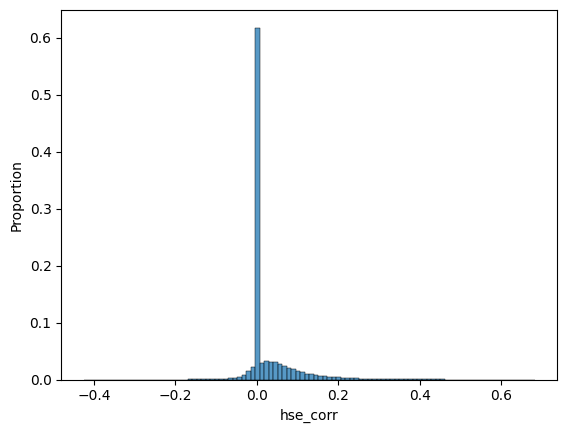

In [7]:
fig, ax = plt.subplots()
_ = sns.histplot(data = df,
                 x='hse_corr', bins=100, stat='proportion', ax = ax)

# ax.set_ylim([0,.1])

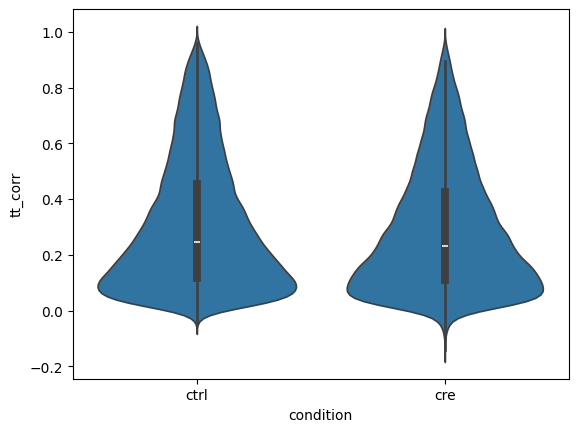

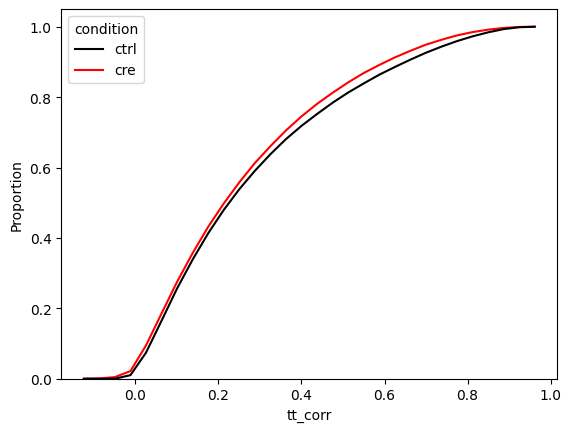

In [8]:

fig, ax = plt.subplots()
_ = sns.violinplot(data=df, x='condition', y='tt_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df,
                x = 'tt_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

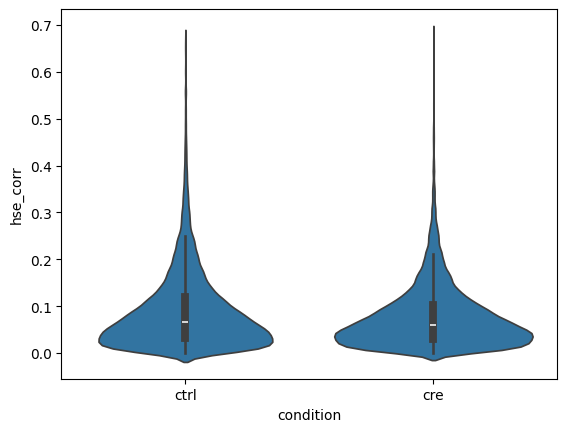

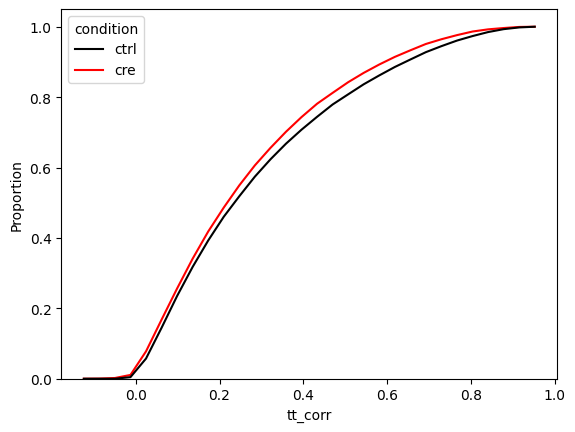

In [9]:

fig, ax = plt.subplots()
_ = sns.violinplot(data=df.loc[nonzero_mask,:], x='condition', y='hse_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df.loc[nonzero_mask,:],
                x = 'tt_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

In [10]:


print(df.loc[cre_mask*nonzero_mask,'tt_corr'].mean(), df.loc[cre_mask*(~nonzero_mask),'tt_corr'].mean())
print(df.loc[~cre_mask*nonzero_mask,'tt_corr'].mean(), df.loc[~cre_mask*(~nonzero_mask),'tt_corr'].mean())

0.2870415356347407 0.28534561654789947
0.3099764733521967 0.30413503785276436


In [11]:
df.head()

,condition,mouse,ttype,hse_day,tt_day,hse_corr,tt_corr
0,ctrl,4467331.1,fam,0,1,0.040229,0.512902
1,ctrl,4467331.1,fam,0,1,0.081189,0.479035
2,ctrl,4467331.1,fam,0,1,0.000000,0.859526
3,ctrl,4467331.1,fam,0,1,0.000000,0.462268
4,ctrl,4467331.1,fam,0,1,0.096802,0.606260


In [12]:
df['hse_corr_z'] = np.arctanh(df['hse_corr'])
df['tt_corr_z'] = np.arctanh(df['tt_corr'])
df_pos = df.loc[nonzero_mask].groupby(['condition','hse_day', 'ttype', 'mouse']).mean().reset_index()
df_neg = df.loc[~nonzero_mask].groupby(['condition','hse_day',  'ttype', 'mouse']).mean().reset_index()
df_pos['positive']= True
df_neg['positive']= False

In [13]:
df_grouped = pd.concat([df_pos, df_neg], axis=0)

In [14]:
df_grouped.head()

,condition,hse_day,ttype,mouse,tt_day,hse_corr,tt_corr,hse_corr_z,tt_corr_z,positive
0,cre,0,fam,4467975.1,3.044503,0.073016,0.205789,0.073403,0.218082,True
1,cre,0,fam,4467975.2,2.895652,0.114514,0.315242,0.115611,0.355775,True
2,cre,0,fam,4467975.3,2.920428,0.057966,0.300207,0.058100,0.336727,True
3,cre,0,fam,4467975.4,2.927733,0.053971,0.277644,0.054098,0.316485,True
4,cre,0,fam,4467975.5,3.034164,0.063316,0.292434,0.063542,0.323570,True


Text(0.5, 1.0, 'Cre: Nov')

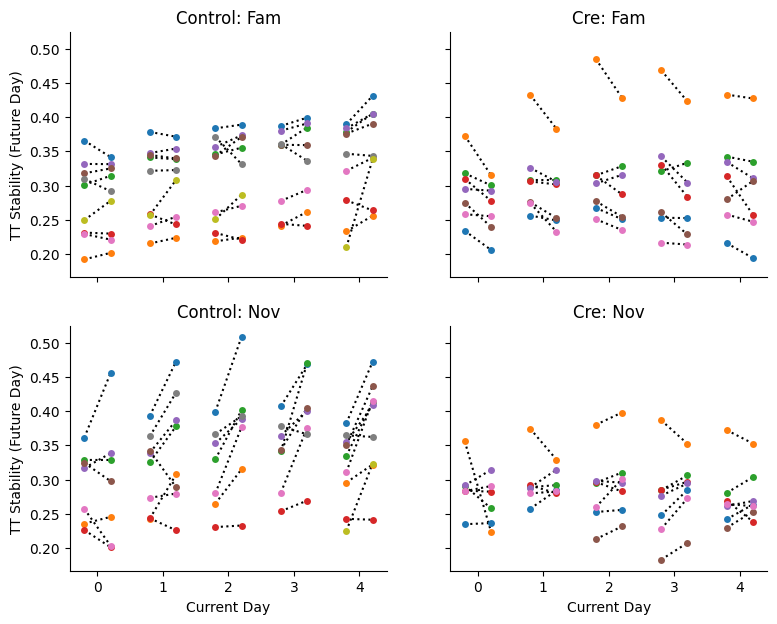

In [17]:
fig, ax = plt.subplots(2,2, figsize=(9,7), sharex=True, sharey=True)

for k, ttype in enumerate(['fam','nov']):
    old_ind = 0
    for i, mouse in enumerate(ctrl_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='ctrl') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='tt_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,0])
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,0].collections[d].get_offsets(), ax[k,0].collections[d+1].get_offsets()):
                ax[k,0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
        


    old_ind = 0
    for i, mouse in enumerate(ko_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='cre') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='tt_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,1])
        
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,1].collections[d].get_offsets(), ax[k,1].collections[d+1].get_offsets()):
                ax[k,1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
    
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Current Day')
    a.set_ylabel('TT Stability (Future Day)')
ax[0,0].set_title('Control: Fam')
ax[0,1].set_title('Cre: Fam')
ax[1,0].set_title('Control: Nov')
ax[1,1].set_title('Cre: Nov')


In [ ]:
import statsmodels.formula.api as smf
df_tmp = df_grouped.copy()
df_tmp['condition'] = df_tmp['condition'].astype('category')
df_tmp['mouse'] = df_tmp['mouse'].astype('category')
df_tmp['hse_day'] = df_tmp['hse_day'].astype('category')
df_tmp['ttype'] = df_tmp['ttype'].astype('category')
df_tmp['positive'] = df_tmp['positive'].astype('category')
df_tmp['tt_corr_rank'] = df_tmp['tt_corr'].rank()




In [ ]:
_df_tmp = df_tmp.loc[df_tmp['ttype']=='fam']
model = smf.mixedlm("tt_corr_rank ~ positive * condition + hse_day", 
                    _df_tmp, groups=_df_tmp["mouse"])

res = model.fit()
res.summary()



<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
=================================================================================
Model:                     MixedLM        Dependent Variable:        tt_corr_rank
No. Observations:          158            Method:                    REML        
No. Groups:                16             Scale:                     855.9839    
Min. group size:           8              Log-Likelihood:            -763.4726   
Max. group size:           10             Converged:                 Yes         
Mean group size:           9.9                                                   
---------------------------------------------------------------------------------
                                    Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                           115.278   32.262  3.573 0.000  52.045 178.511
positive[T.True]                    -24.886    6.994 -3.558 0.000 -38.593 -11.178
condition[T.ctrl]                     3.654   42.576  0.086 0.932 -79.794  87.101
hse_day[T.1]                         27.406    7.314  3.747 0.000  13.070  41.742
hse_day[T.2]                         33.469    7.314  4.576 0.000  19.133  47.805
hse_day[T.3]                         41.861    7.465  5.608 0.000  27.230  56.491
hse_day[T.4]                         55.875    7.314  7.639 0.000  41.539  70.211
positive[T.True]:condition[T.ctrl]   37.613    9.371  4.014 0.000  19.246  55.980
Group Var                          6964.368   95.656                             
=================================================================================

"""

Shapiro-Wilk: W=0.952, p=7.66e-05
D'Agostino: χ²=29.293, p=4.36e-07


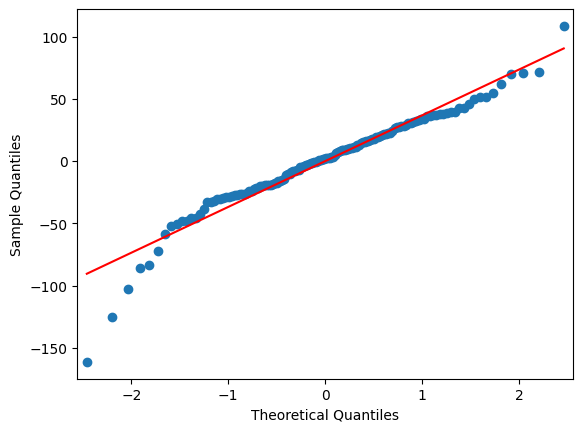

In [29]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [28]:
_df_tmp = df_tmp.loc[df_tmp['ttype']=='nov']
model = smf.mixedlm("tt_corr_rank ~ positive * condition + hse_day", 
                    _df_tmp, groups=_df_tmp["mouse"])

res = model.fit()
res.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                     Mixed Linear Model Regression Results
================================================================================
Model:                    MixedLM        Dependent Variable:        tt_corr_rank
No. Observations:         142            Method:                    REML        
No. Groups:               16             Scale:                     1596.1906   
Min. group size:          2              Log-Likelihood:            -720.6035   
Max. group size:          10             Converged:                 Yes         
Mean group size:          8.9                                                   
--------------------------------------------------------------------------------
                                    Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------
Intercept                            73.633   29.018 2.537 0.011  16.759 130.507
positive[T.True]                      4.606    9.836 0.468 0.640 -14.671  23.883
condition[T.ctrl]                    49.417   37.579 1.315 0.188 -24.236 123.070
hse_day[T.1]                         33.771   10.930 3.090 0.002  12.349  55.194
hse_day[T.2]                         48.707   11.046 4.410 0.000  27.058  70.357
hse_day[T.3]                         47.857   11.045 4.333 0.000  26.208  69.505
hse_day[T.4]                         43.909   10.797 4.067 0.000  22.747  65.070
positive[T.True]:condition[T.ctrl]   35.052   13.444 2.607 0.009   8.702  61.402
Group Var                          5177.582   54.076                            
================================================================================

"""

In [ ]:
# permutation test

In [ ]:
# rerun with across day correlation